In [16]:
from scripts.preprocessing import load_data, test_stationarity
from scripts.econometrics_models import ols_regression
from scripts.ml_models import prepare_ml_data, train_xgb_model
from scripts.evaluation import calculate_metrics
from scripts.visualization import plot_predictions

import pandas as pd

In [20]:
# Ładowanie danych
df = load_data('data/dane_2010plus.xlsx')
df.index = pd.to_datetime(df.index, format='%Y%m')

# Test stacjonarności
stationarity = test_stationarity(df['stopa_bezrobocia'])

# Model OLS
X, y = df.drop('stopa_bezrobocia', axis=1), df['stopa_bezrobocia']
ols_result = ols_regression(X, y)
print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:       stopa_bezrobocia   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     166.9
Date:                Mon, 14 Jul 2025   Prob (F-statistic):           3.22e-69
Time:                        22:35:05   Log-Likelihood:                -293.30
No. Observations:                 180   AIC:                             600.6
Df Residuals:                     173   BIC:                             623.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

c:\Users\lapto\Magisterka_Pawel\master_degree\scripts\preprocessing.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_excel(filepath, parse_dates=['rok_miesiac'])


In [23]:
# Model ML
X_ml, y_ml = prepare_ml_data(df, 'stopa_bezrobocia', lag_range=6)
X_train, X_test = X_ml.iloc[:-24], X_ml.iloc[-24:]
y_train, y_test = y_ml.iloc[:-24], y_ml.iloc[-24:]

# Usunięcie znaków specjalnych z nazw kolumn
X_train.columns = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<>]', '', regex=True)

model = train_xgb_model(X_train, y_train)
predictions = model.predict(X_test)

# Ocena modelu
metrics = calculate_metrics(y_test, predictions)
print(metrics)

{'MSE': 0.06833914349243704, 'RMSE': np.float64(0.2614175653861788), 'MAE': 0.24051294724146524, 'R2': -0.7957731136698789}


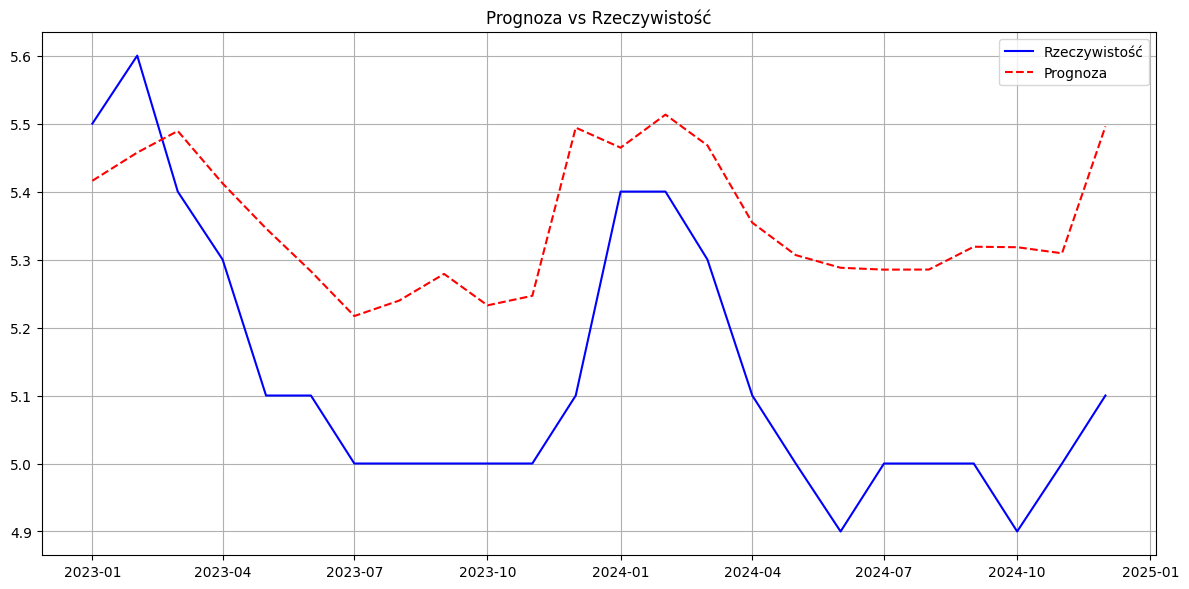

In [24]:
# Wizualizacja
plot_predictions(y_test, predictions)